#                      ============== YouTube AdView Prediction ================

### **Table of Content:**
1. Introduction
2. Install & Import Libraries
3. Load Datasets
4. Exploratory Data Analysis
5. Feature Engineering
6. Model Development
7. Find Prediction


# 2.Install and Import Libraries

In [ ]:
#!pip install missingno
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
from scipy.stats import norm, skew
from sklearn.preprocessing import PowerTransformer
import warnings
warnings.filterwarnings('ignore')
print("Libraries Imported!")


Libraries Imported!


**Load DataSet-Train-Data**

In [ ]:
train_df=pd.read_csv('train.csv')
train_df.head()


,vidid,adview,views,likes,dislikes,comment,published,duration,category
0,VID_5926,2.0,NaN,327,121,23,2016-03-22,PT2M33S,D
1,VID_14380,2.0,225722,794,77,109,2016-08-08,PT1M40S,D
2,VID_10292,1.0,39979,84,9,12,2015-08-04,PT2H35M19S,D
3,NaN,NaN,NaN,NaN,NaN,NaN,2016-07-14,NaN,NaN
4,VID_16217,5.0,999882,2296,318,301,2016-04-12,PT1H29M23S,E


**Data Shape-Train Data**

In [ ]:
train_df.shape

(13000, 9)

**Data Type-Train Data**

In [ ]:
train_dtype = train_df.dtypes
train_dtype.value_counts()

,count
object,8
float64,1


**Visualize Missing values-Train Data**

<Axes: >

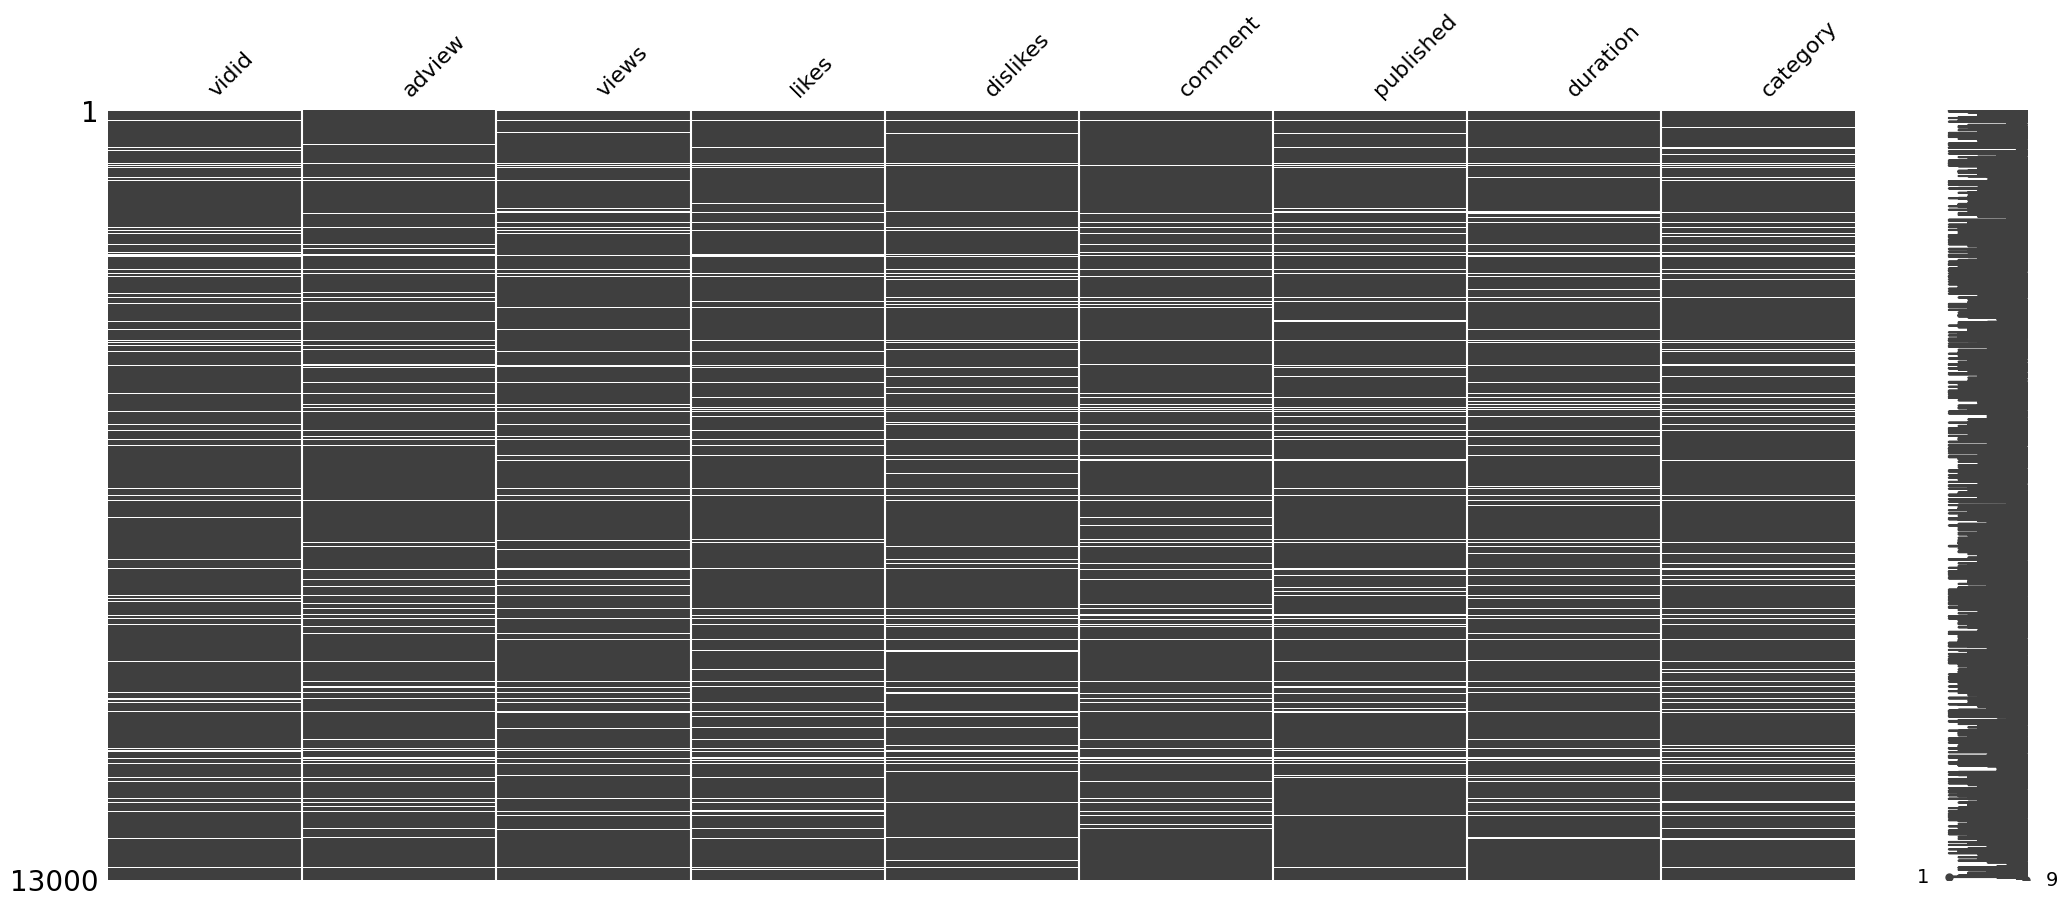

In [ ]:
msno.matrix(train_df)

**Data Cleaning**

In [ ]:
# ======== DATA ClEANING ========
# Identifying missing values
train_df.isnull()

,vidid,adview,views,likes,dislikes,comment,published,duration,category
0,False,False,True,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,True,True,True,True,True,True,False,True,True
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
12995,False,False,False,False,False,False,False,False,False
12996,False,False,False,False,False,False,False,False,False
12997,False,False,False,False,False,False,False,False,False
12998,False,False,False,False,False,False,False,False,False


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13000 entries, 0 to 12999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   vidid      11889 non-null  object 
 1   adview     11928 non-null  float64
 2   views      11893 non-null  object 
 3   likes      11915 non-null  object 
 4   dislikes   11933 non-null  object 
 5   comment    11883 non-null  object 
 6   published  11943 non-null  object 
 7   duration   11927 non-null  object 
 8   category   11892 non-null  object 
dtypes: float64(1), object(8)
memory usage: 914.2+ KB


**Null Values-Train Data**

In [ ]:
train_df.apply(lambda x:sum(x.isnull()),axis=0)

,0
vidid,1111
adview,1072
views,1107
likes,1085
dislikes,1067
comment,1117
published,1057
duration,1073
category,1108


Converting Duration Column into Seconds

In [ ]:
import pandas as pd

# Function to convert YouTube duration strings to seconds
def checki(x):
    if isinstance(x, str):
        if x.startswith("PT"):
            x = x[2:]

        h, m, s = 0, 0, 0
        mm = ''

        # Iterate through characters in the string
        for char in x:
            if char.isdigit():
                mm += char
            elif char == 'H':
                h = int(mm) if mm else 0
                mm = ''
            elif char == 'M':
                m = int(mm) if mm else 0
                mm = ''
            elif char == 'S':
                s = int(mm) if mm else 0
                mm = ''

        # Return total duration in seconds
        return h * 3600 + m * 60 + s
    else:
        # Handle non-string values
        return 0


train_df1 = pd.read_csv('/content/train.csv', dtype={'duration': str})

train_df['duration'] = train_df1['duration'].apply(checki)

train_df

,vidid,adview,views,likes,dislikes,comment,published,duration,category
0,VID_5926,2.0,NaN,327,121,23,2016-03-22,153,D
1,VID_14380,2.0,225722,794,77,109,2016-08-08,100,D
2,VID_10292,1.0,39979,84,9,12,2015-08-04,9319,D
3,NaN,NaN,NaN,NaN,NaN,NaN,2016-07-14,0,NaN
4,VID_16217,5.0,999882,2296,318,301,2016-04-12,5363,E
...,...,...,...,...,...,...,...,...,...
12995,VID_4849,23.0,75032,78,6,3,2014-03-11,626,D
12996,VID_15032,97.0,739419,1635,169,52,2013-12-17,195,D
12997,VID_1031,1.0,244274,2005,127,581,2015-07-02,120,B
12998,VID_20660,3.0,2146751,2499,460,196,2014-01-01,815,G


**Remove-Duplicates-Train Data**

In [ ]:
# Romoving duplicates Values
train_df.drop_duplicates()

,vidid,adview,views,likes,dislikes,comment,published,duration,category
0,VID_5926,2.0,NaN,327,121,23,2016-03-22,153,D
1,VID_14380,2.0,225722,794,77,109,2016-08-08,100,D
2,VID_10292,1.0,39979,84,9,12,2015-08-04,9319,D
3,NaN,NaN,NaN,NaN,NaN,NaN,2016-07-14,0,NaN
4,VID_16217,5.0,999882,2296,318,301,2016-04-12,5363,E
...,...,...,...,...,...,...,...,...,...
12995,VID_4849,23.0,75032,78,6,3,2014-03-11,626,D
12996,VID_15032,97.0,739419,1635,169,52,2013-12-17,195,D
12997,VID_1031,1.0,244274,2005,127,581,2015-07-02,120,B
12998,VID_20660,3.0,2146751,2499,460,196,2014-01-01,815,G


In [ ]:
train_df1 = train_df.dropna()
train_df1

,vidid,adview,views,likes,dislikes,comment,published,duration,category
1,VID_14380,2.0,225722,794,77,109,2016-08-08,100,D
2,VID_10292,1.0,39979,84,9,12,2015-08-04,9319,D
4,VID_16217,5.0,999882,2296,318,301,2016-04-12,5363,E
6,VID_8199,1.0,38841,25,11,2,2015-03-11,10471,D
7,VID_4958,2.0,1542644,409,326,36,2011-11-12,172,D
...,...,...,...,...,...,...,...,...,...
12995,VID_4849,23.0,75032,78,6,3,2014-03-11,626,D
12996,VID_15032,97.0,739419,1635,169,52,2013-12-17,195,D
12997,VID_1031,1.0,244274,2005,127,581,2015-07-02,120,B
12998,VID_20660,3.0,2146751,2499,460,196,2014-01-01,815,G


In [ ]:
train_df1.apply(lambda x:sum(x.isnull()),axis=0)

,0
vidid,0
adview,0
views,0
likes,0
dislikes,0
comment,0
published,0
duration,0
category,0


**Transfromation-Train Data**

In [ ]:
import numpy as np
import pandas as pd
# Convert 'published' column to datetime if it's not already
train_df1['published'] = pd.to_datetime(train_df1['published'], errors='coerce')
# Making a coulmn year for published years
train_df1['year'] = train_df1['published'].dt.year
train_df1

,vidid,adview,views,likes,dislikes,comment,published,duration,category,year
1,VID_14380,2.0,225722,794,77,109,2016-08-08,100,D,2016
2,VID_10292,1.0,39979,84,9,12,2015-08-04,9319,D,2015
4,VID_16217,5.0,999882,2296,318,301,2016-04-12,5363,E,2016
6,VID_8199,1.0,38841,25,11,2,2015-03-11,10471,D,2015
7,VID_4958,2.0,1542644,409,326,36,2011-11-12,172,D,2011
...,...,...,...,...,...,...,...,...,...,...
12995,VID_4849,23.0,75032,78,6,3,2014-03-11,626,D,2014
12996,VID_15032,97.0,739419,1635,169,52,2013-12-17,195,D,2013
12997,VID_1031,1.0,244274,2005,127,581,2015-07-02,120,B,2015
12998,VID_20660,3.0,2146751,2499,460,196,2014-01-01,815,G,2014


**Normalization-Train Data**

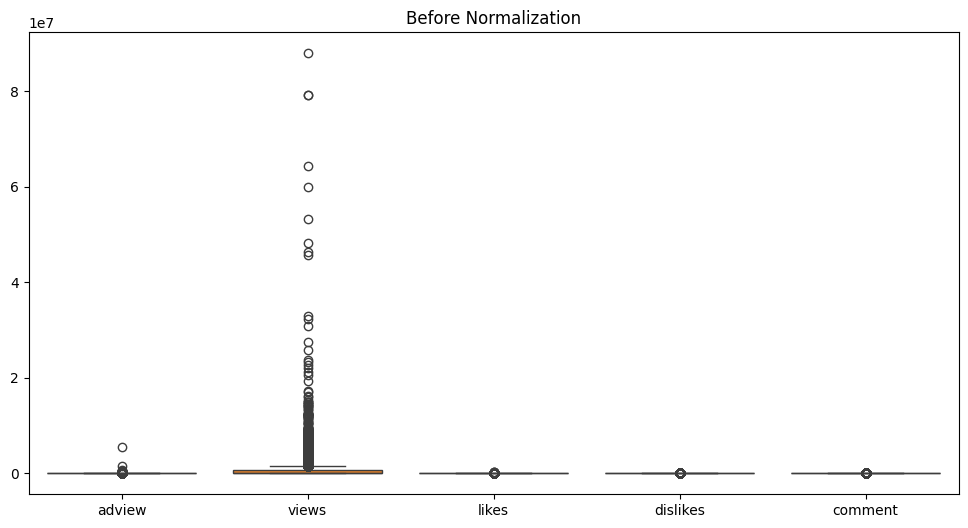

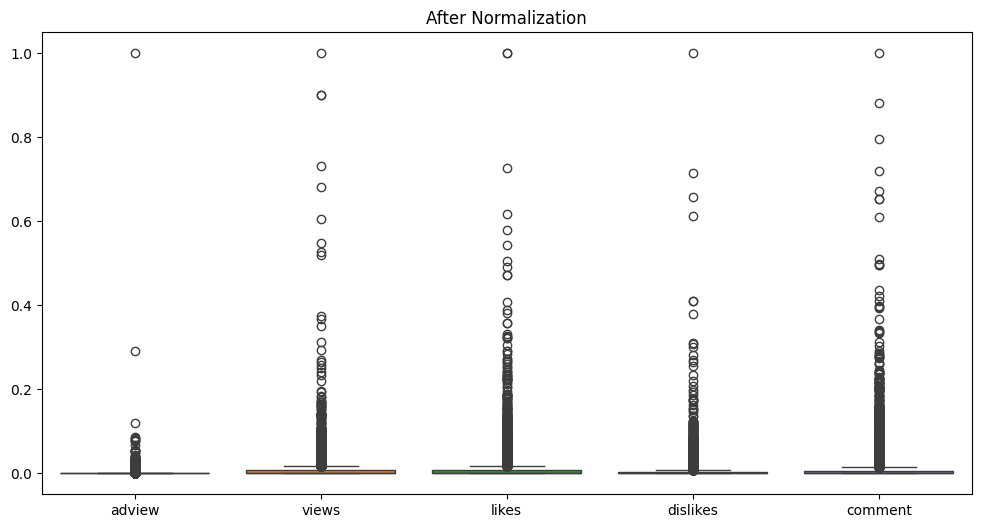

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt

scaler = MinMaxScaler()

columns_to_normalize = ['adview', 'views', 'likes', 'dislikes', 'comment']

for column in columns_to_normalize:
    train_df1[column] = pd.to_numeric(train_df1[column], errors='coerce')

train_df1[columns_to_normalize] = train_df1[columns_to_normalize].fillna(0)

plt.figure(figsize=(12, 6))
sns.boxplot(data=train_df1[columns_to_normalize])
plt.title('Before Normalization')
plt.show()

train_df1[columns_to_normalize] = scaler.fit_transform(train_df1[columns_to_normalize])

plt.figure(figsize=(12, 6))
sns.boxplot(data=train_df1[columns_to_normalize])
plt.title('After Normalization')
plt.show()

PART 3: EXPLORATORY DATA ANALYSIS AND **VISUALIZATION**

**Statistical Analysis-Train Data**

In [ ]:
train_df1.describe()

,adview,published,duration,year
count,1.041200e+04,10412,10412.000000,10412.000000
mean,2.260580e+03,2014-12-16 22:49:03.065693184,1020.577603,2014.446696
min,1.000000e+00,2005-10-24 00:00:00,0.000000,2005.000000
25%,1.000000e+00,2013-11-14 00:00:00,183.000000,2013.000000
50%,2.000000e+00,2015-06-12 00:00:00,319.000000,2015.000000
75%,6.000000e+00,2016-06-07 06:00:00,711.000000,2016.000000
max,5.429665e+06,2017-04-23 00:00:00,38516.000000,2017.000000
std,5.817382e+04,NaN,2280.023818,1.776522


**Visualize missing value using Misingno**

<Axes: >

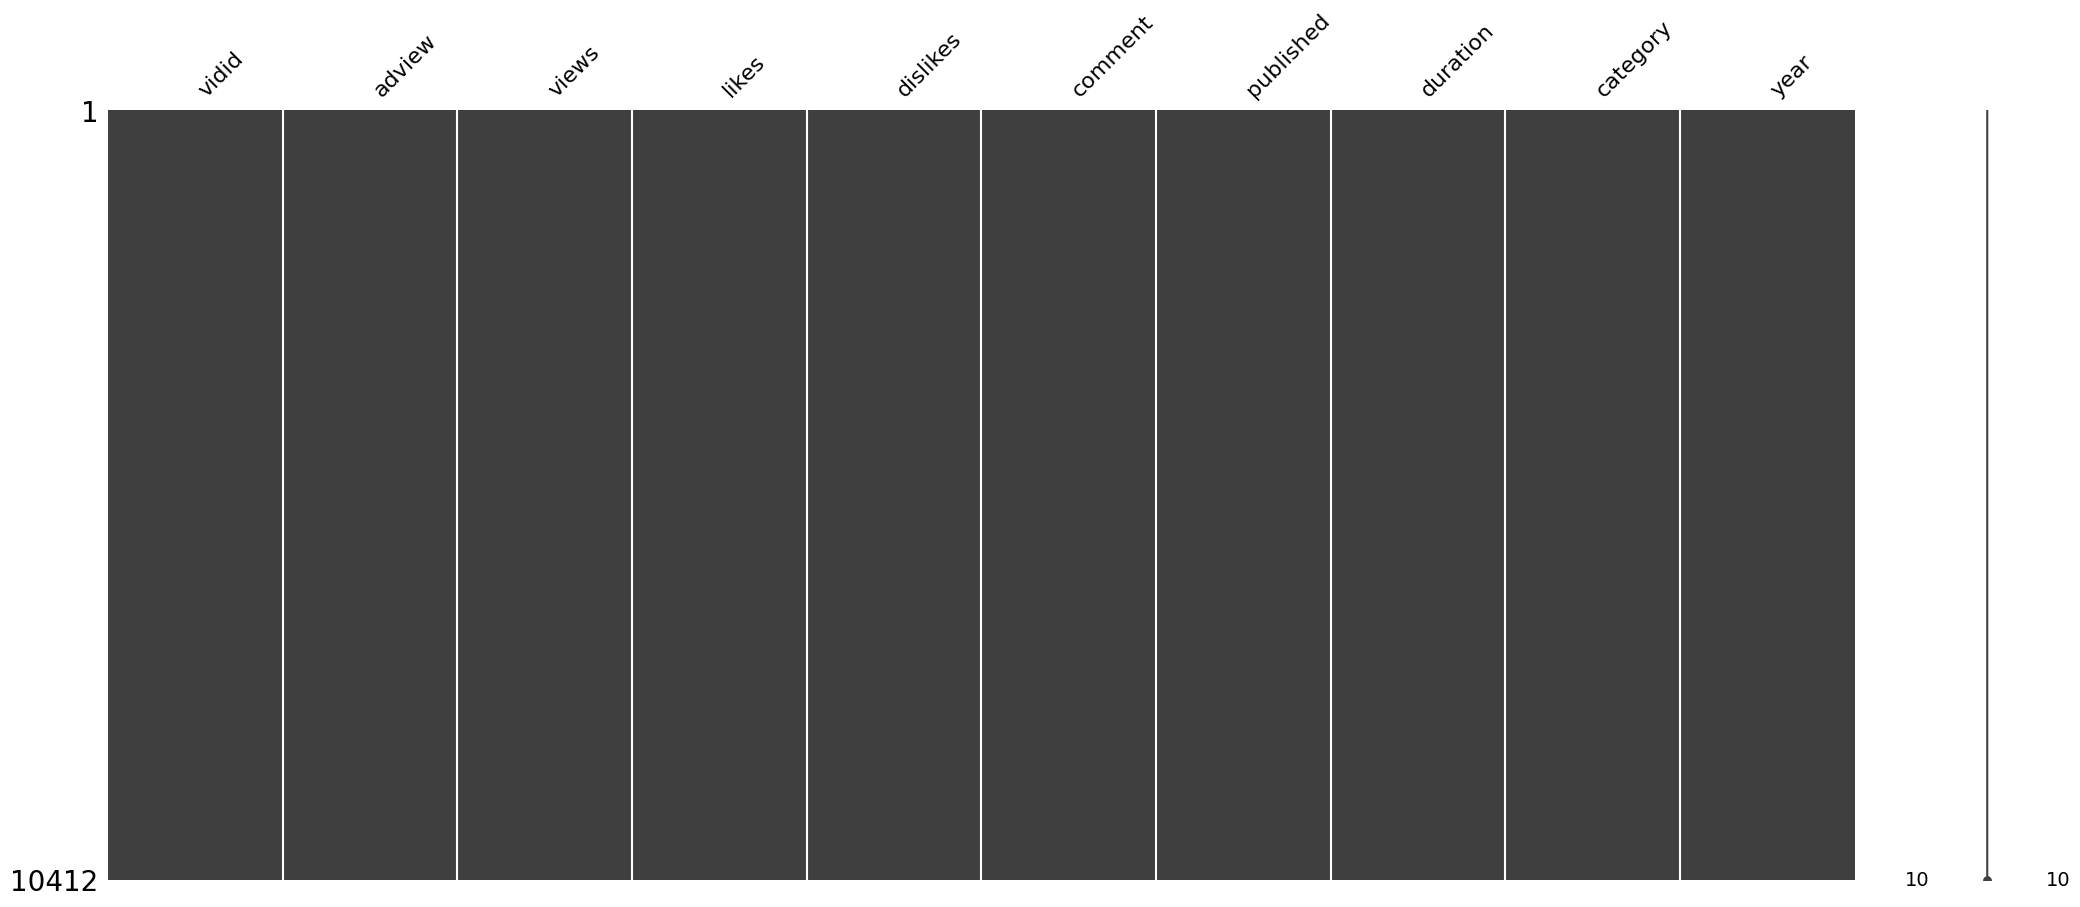

In [ ]:
msno.matrix(train_df1)

**Univariate Analysis-train Data**

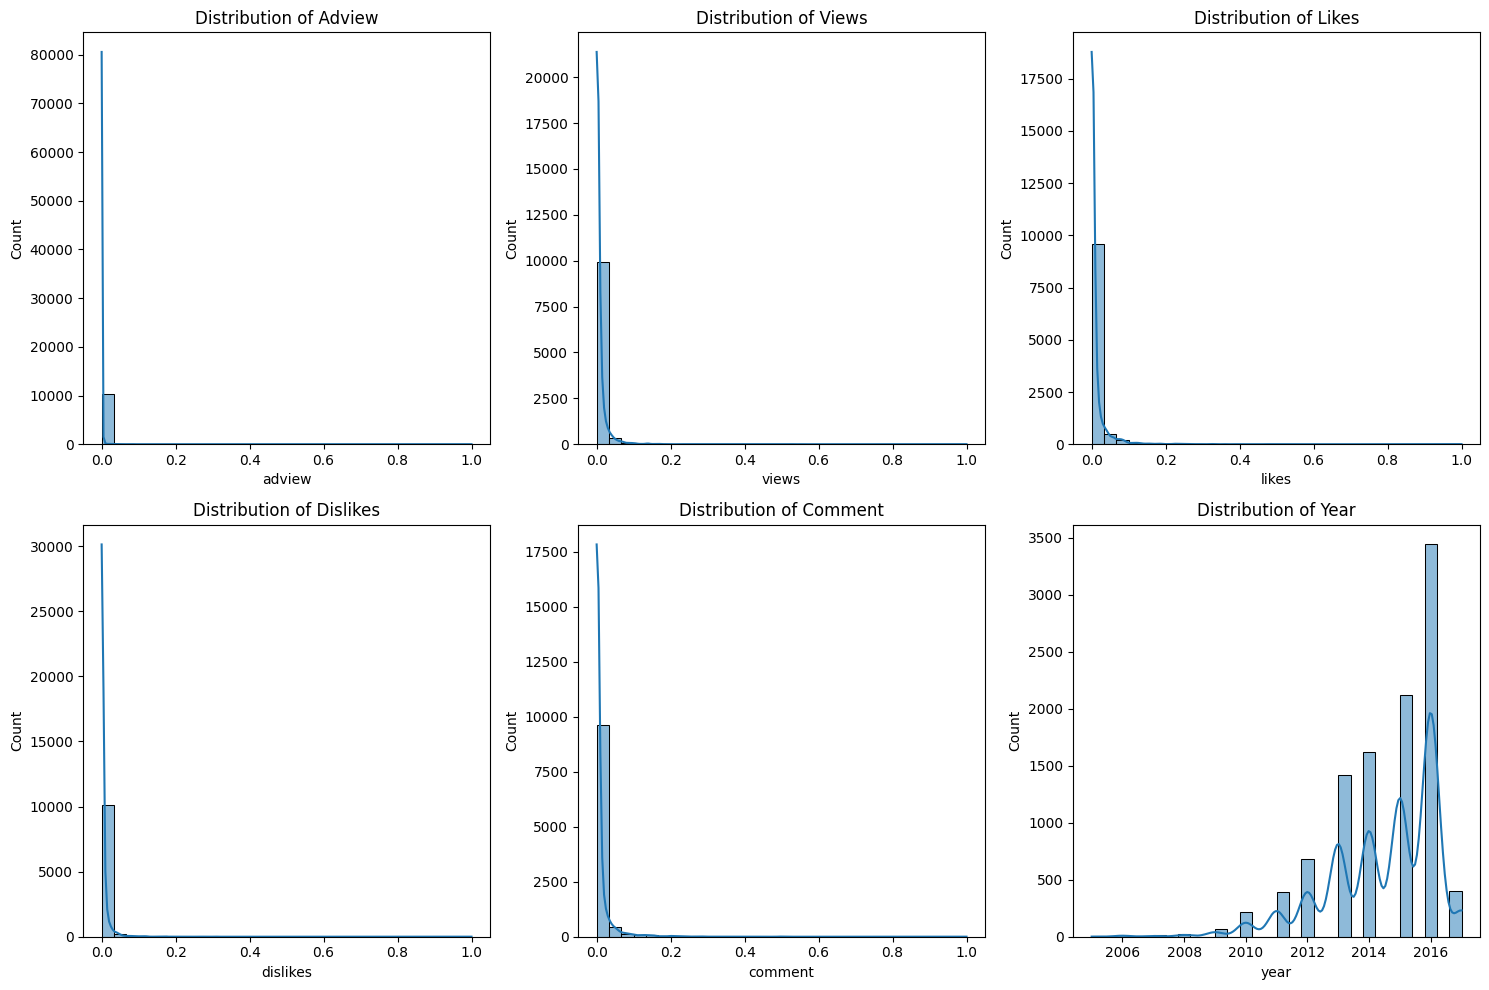

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

cols_to_plot = ['adview', 'views', 'likes', 'dislikes', 'comment', 'year']

for i, col in enumerate(cols_to_plot):
    sns.histplot(train_df1[col].dropna(), bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col.capitalize()}')

if len(cols_to_plot) < len(axes):
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

**Density-Plot-Train-Data**

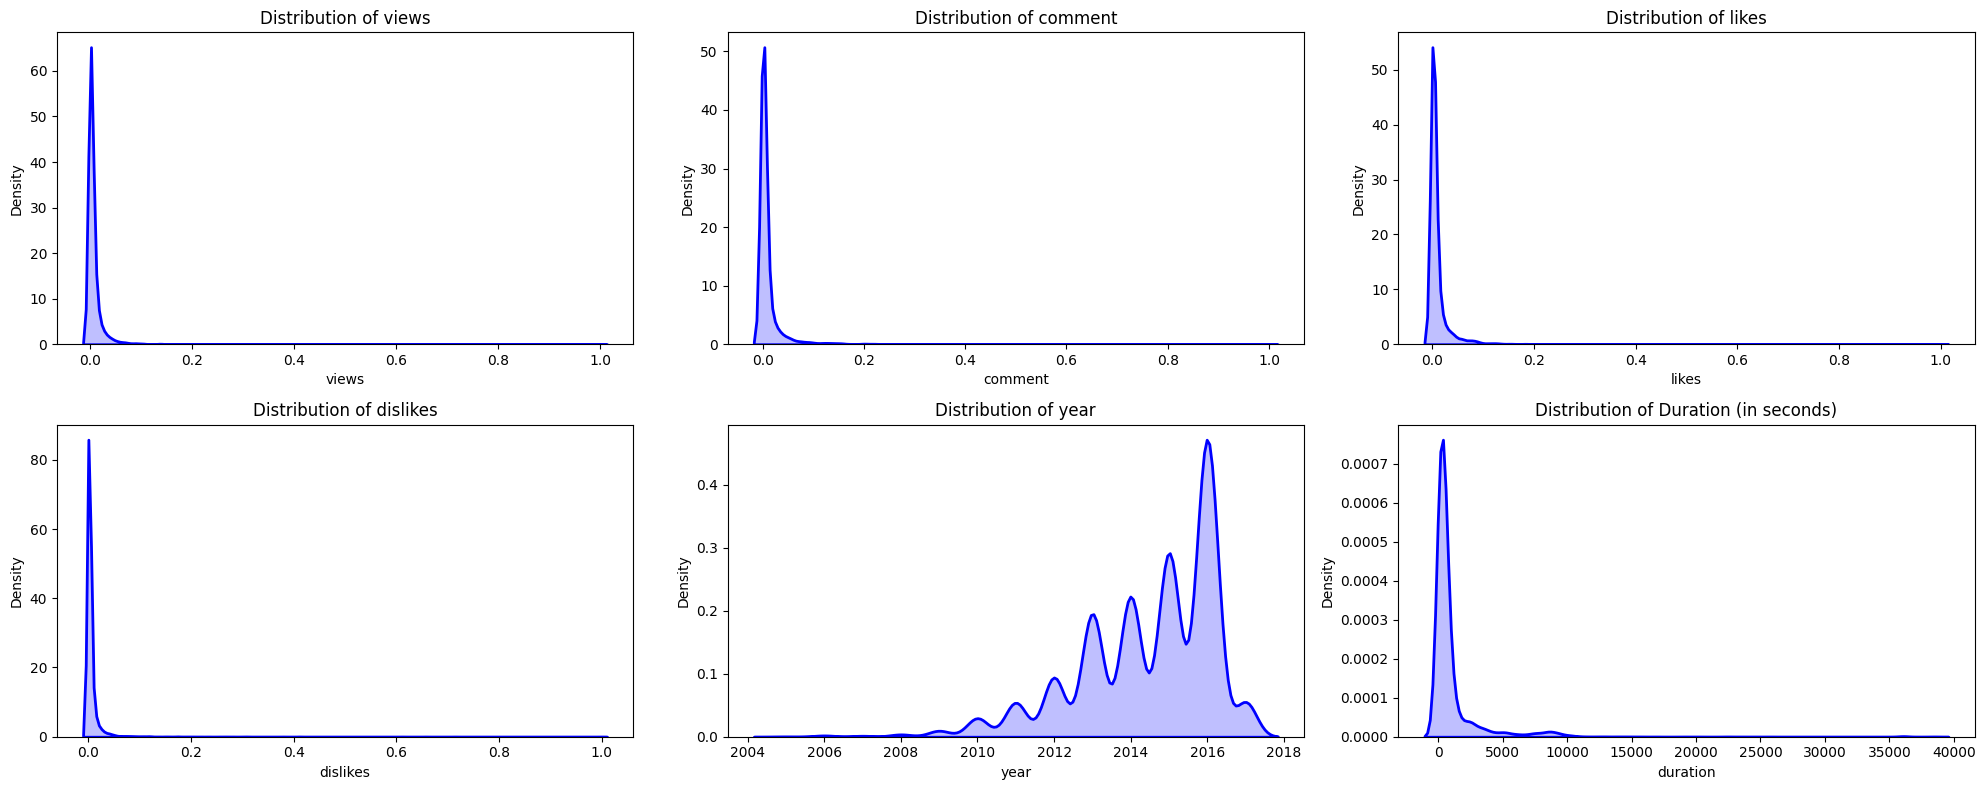

In [ ]:
train_df1['published'] = pd.to_datetime(train_df1['published'], errors='coerce')
train_df1['year'] = train_df1['published'].dt.year

continuous_features = ['views', 'comment', 'likes', 'dislikes', 'year']

if train_df1['duration'].dtype != 'int64' and train_df1['duration'].dtype != 'float64':
    train_df1['duration'] = train_df1['duration'].apply(to_seconds)

# Plotting the distributions
plt.figure(figsize=(20, 8))

# Plot distributions for features other than duration
for pos, feature in enumerate(continuous_features, start=1):
    plt.subplot(2, 3, pos)
    sns.kdeplot(train_df1[feature], fill=True, color='b', linewidth=2)
    plt.title(f'Distribution of {feature}')

# Plot the "Distribution of Duration" graph
plt.subplot(2, 3, 6)
sns.kdeplot(train_df1['duration'], fill=True, color='b', linewidth=2)
plt.title('Distribution of Duration (in seconds)')

plt.tight_layout()
plt.show()

Above distribution shows that:
- The distribution of train are similar for most continous features.
- All distributions are not **normally distributed**.

**Box-Plot-train Data**

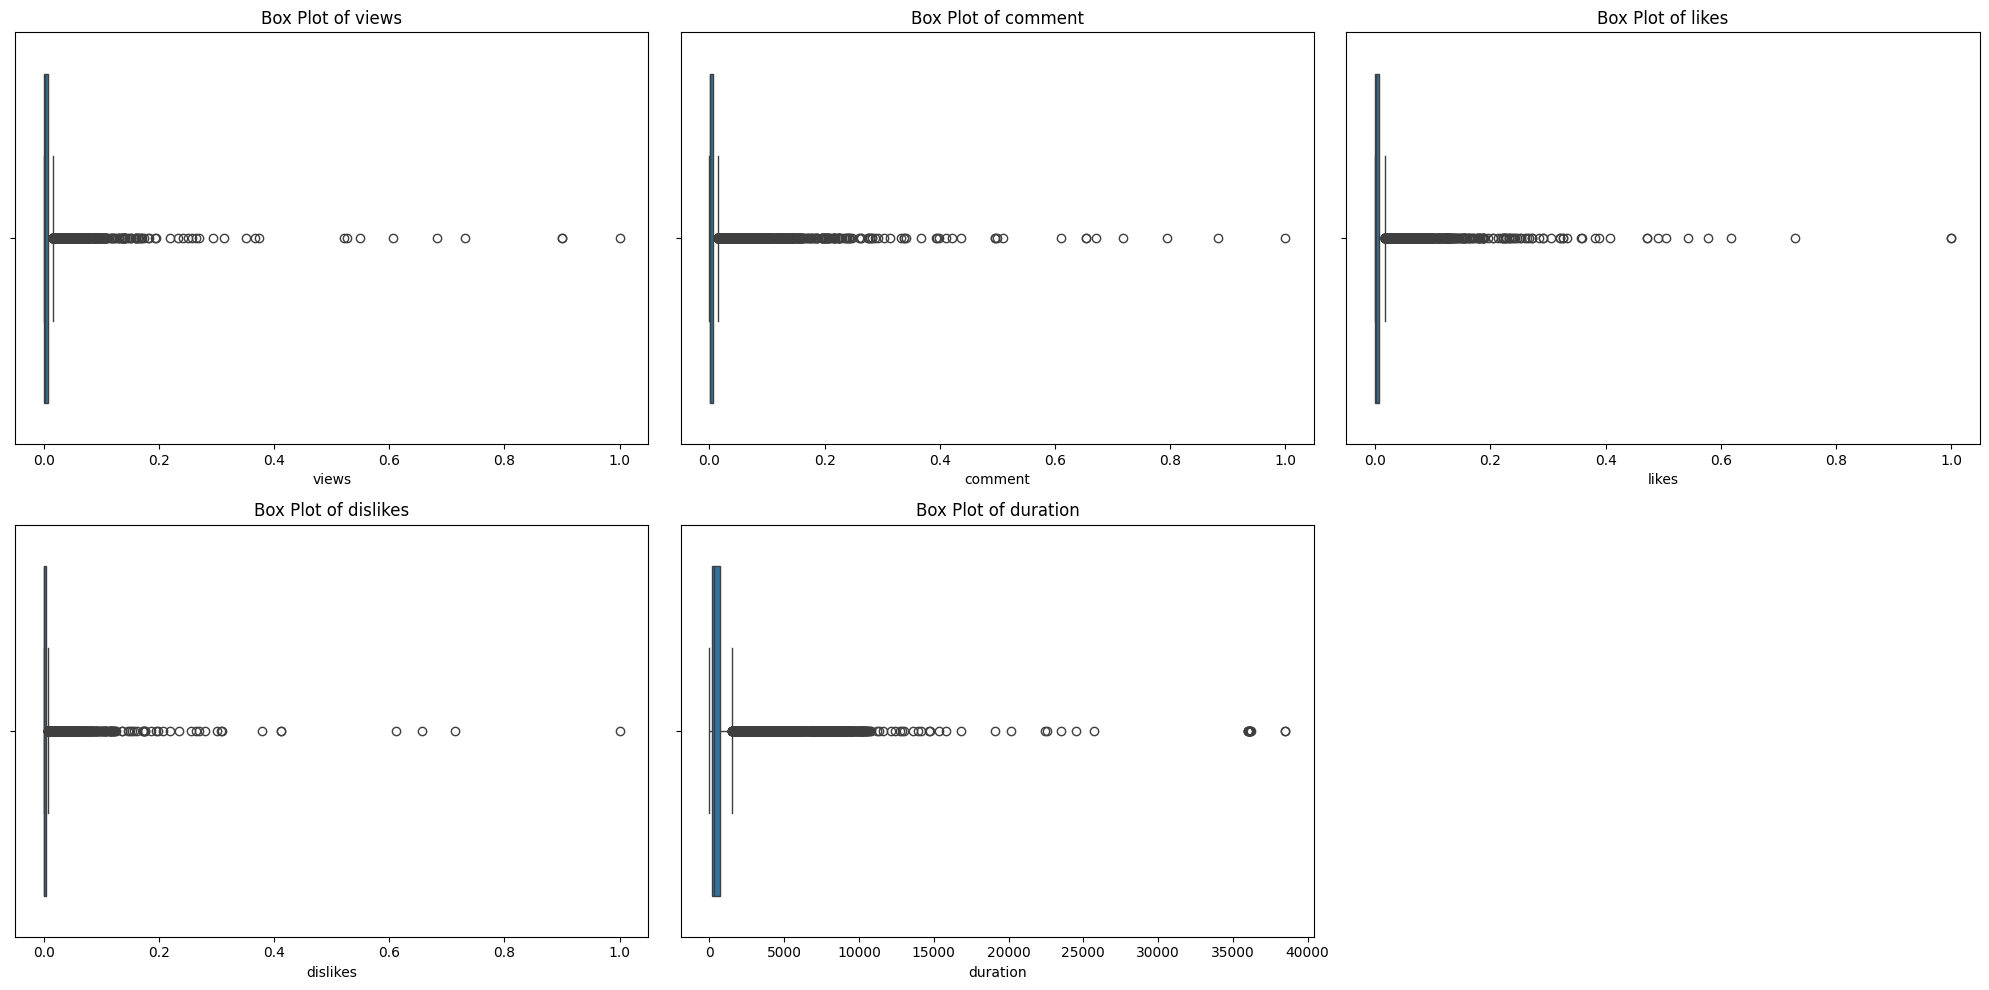

In [ ]:
plt.figure(figsize=(20, 10))
for i, column in enumerate(['views', 'comment', 'likes', 'dislikes', 'duration'], start=1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=train_df1[column])
    plt.title(f'Box Plot of {column}')
plt.tight_layout()
plt.show()

**Bivariate Analysis**

**Scatter-Plot**

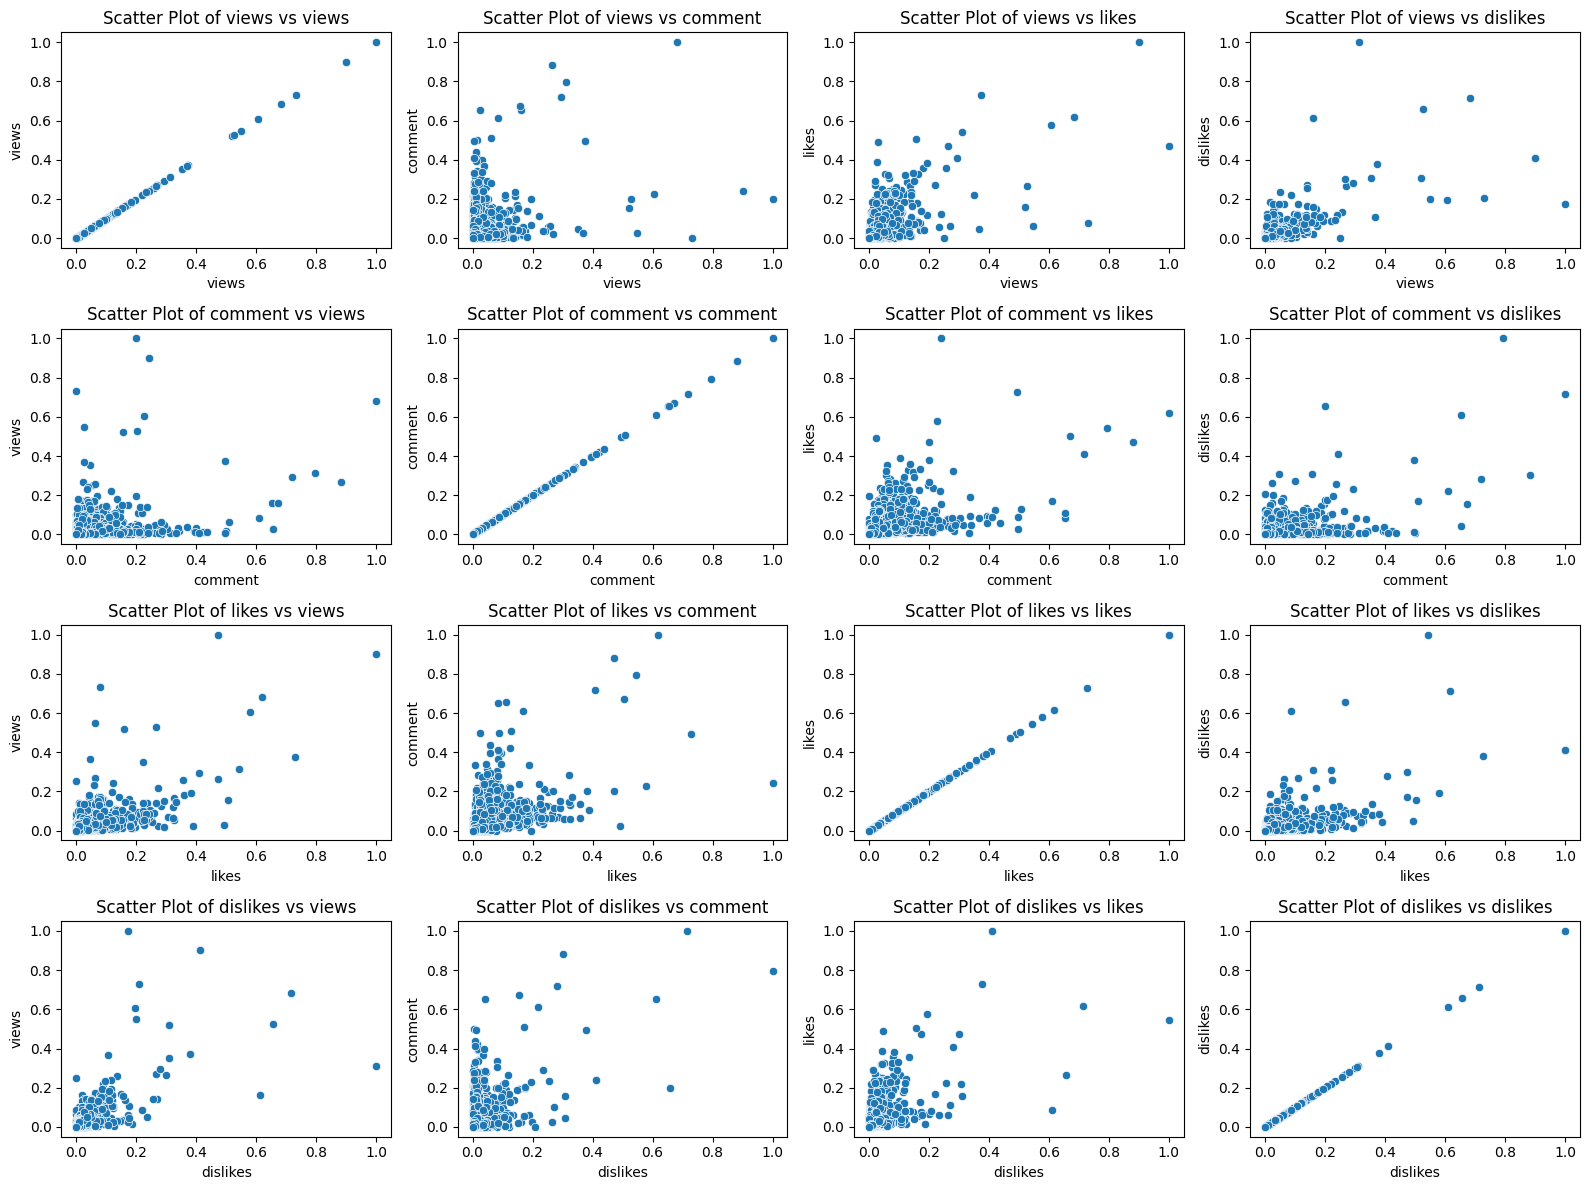

In [ ]:
plt.figure(figsize=(16, 12))
for i, (x_col, y_col) in enumerate([(col1, col2) for col1 in ['views', 'comment', 'likes', 'dislikes'] for col2 in ['views', 'comment', 'likes', 'dislikes']], start=1):
    plt.subplot(4, 4, i)
    sns.scatterplot(x=train_df1[x_col], y=train_df1[y_col])
    plt.title(f'Scatter Plot of {x_col} vs {y_col}')
plt.tight_layout()
plt.show()

**Correlation Matrix**

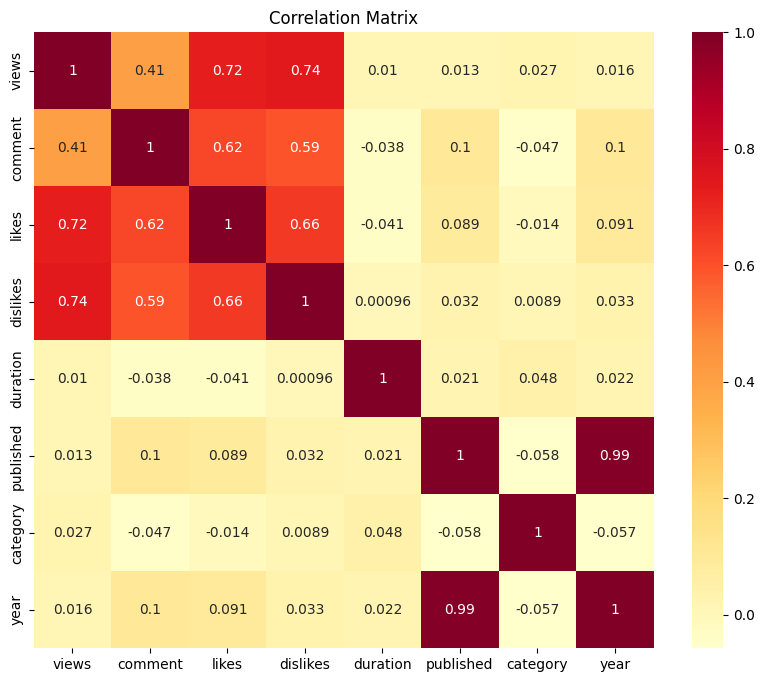

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
train_df1['category'] = label_encoder.fit_transform(train_df1['category'])

correlation_matrix = train_df1[['views', 'comment', 'likes', 'dislikes', 'duration', 'published', 'category', 'year']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='YlOrRd')
plt.title('Correlation Matrix')
plt.show()

**Multiple Line Charts**

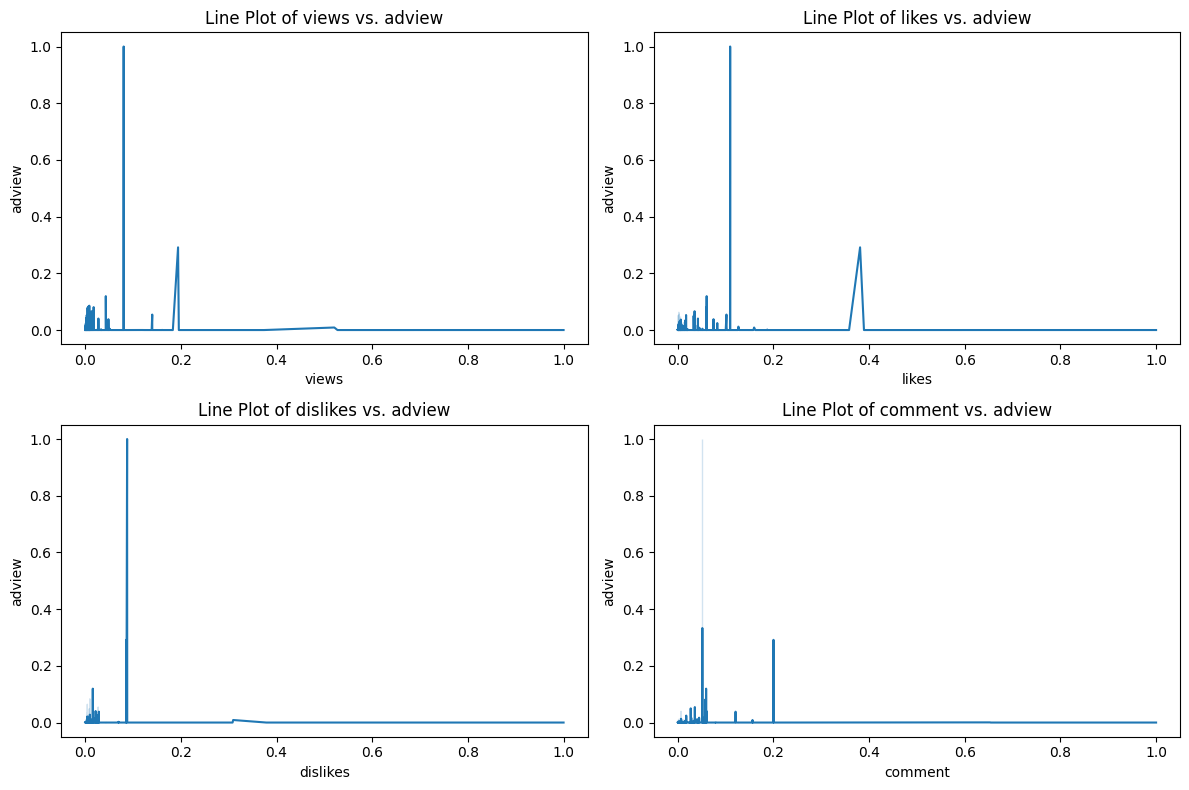

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

features_to_plot = ['views', 'likes', 'dislikes', 'comment']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    sns.lineplot(x=feature, y='adview', data=train_df1, ax=axes[i])
    axes[i].set_title(f"Line Plot of {feature} vs. adview")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('adview')

plt.tight_layout()
plt.show()

**Distribution Comparison - Categorical**
- There are two categorical features. These are **"category", "vidid"**.
- **"vidid"** is the id of video. So it has no impact to target variable.
- So we'll only check the distribution of **"category"** column.

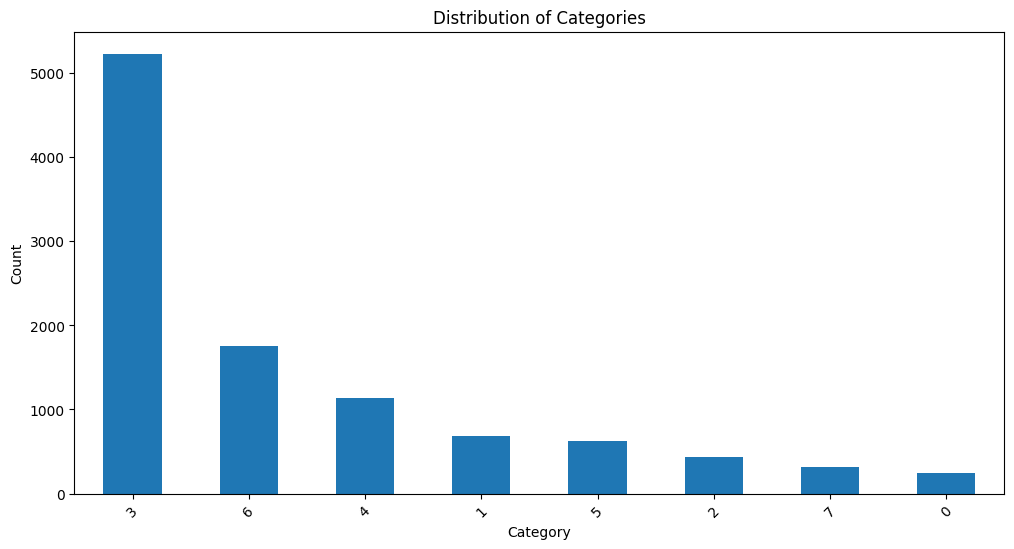

In [ ]:
plt.figure(figsize=(12, 6))
train_df1['category'].value_counts().plot(kind='bar')

plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Distribution of Categories')

plt.xticks(rotation=45)

plt.show()

**Linearity Check**

Here we'll see the linearity between all features and the target variable.



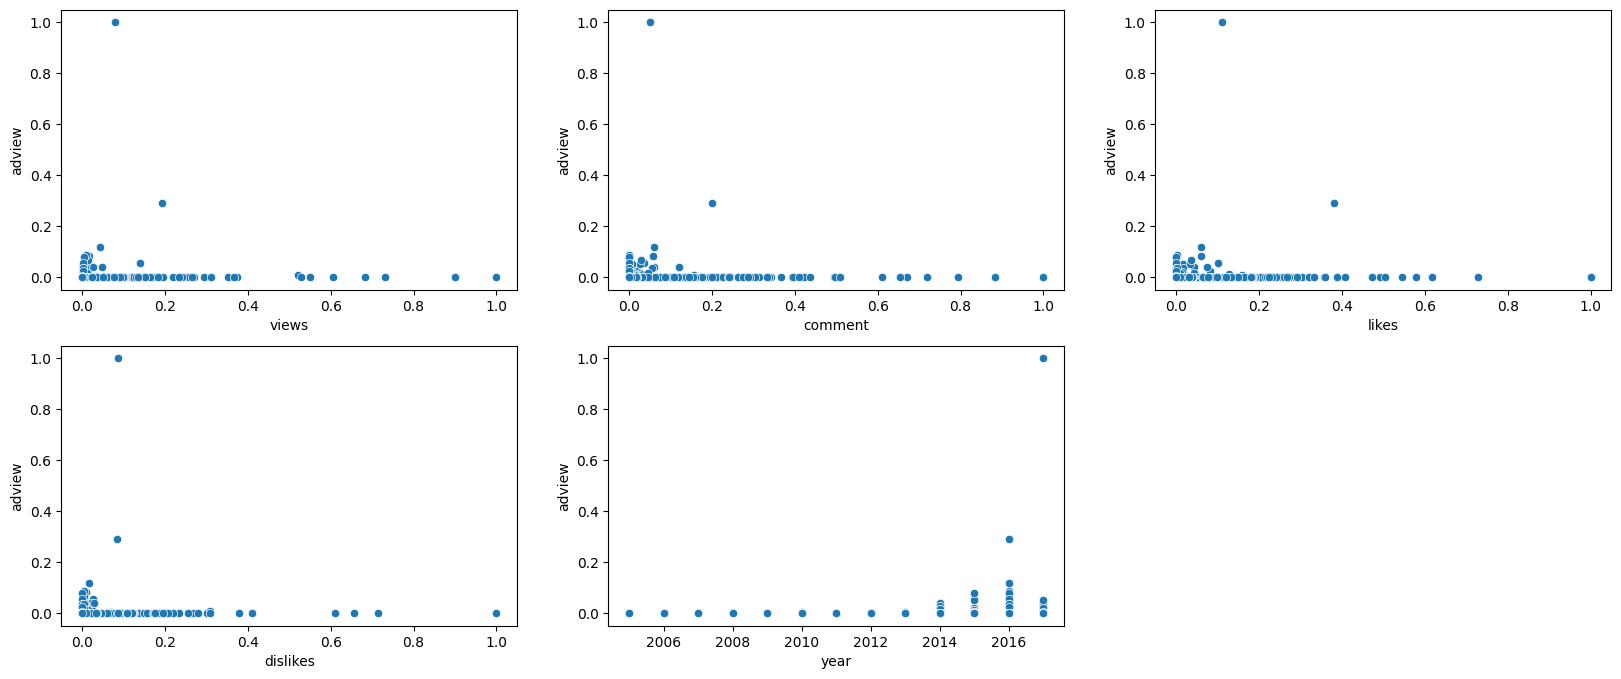

In [ ]:
plt.figure(figsize=(20, 8))
pos = 1
for i, feature in enumerate(continuous_features):
  plt.subplot(2 , 3 , pos)
  sns.scatterplot(data=train_df1, x = feature, y= "adview")
  pos = pos + 1

In [ ]:
train_df1.head()

,vidid,adview,views,likes,dislikes,comment,published,duration,category,year
1,VID_14380,2.0,225722,794,77,109,2016-08-08,100,D,2016
2,VID_10292,1.0,39979,84,9,12,2015-08-04,9319,D,2015
4,VID_16217,5.0,999882,2296,318,301,2016-04-12,5363,E,2016
6,VID_8199,1.0,38841,25,11,2,2015-03-11,10471,D,2015
7,VID_4958,2.0,1542644,409,326,36,2011-11-12,172,D,2011


In [ ]:
# Assigning each category a number for Category feature
category={'A': 1,'B':2,'C':3,'D':4,'E':5,'F':6,'G':7,'H':8}
train_df1["category"]=train_df1["category"].map(category)
train_df1.head()

,vidid,adview,views,likes,dislikes,comment,published,duration,category,year
1,VID_14380,2.0,225722,794,77,109,2016-08-08,100,4,2016
2,VID_10292,1.0,39979,84,9,12,2015-08-04,9319,4,2015
4,VID_16217,5.0,999882,2296,318,301,2016-04-12,5363,5,2016
6,VID_8199,1.0,38841,25,11,2,2015-03-11,10471,4,2015
7,VID_4958,2.0,1542644,409,326,36,2011-11-12,172,4,2011


In [ ]:
# Removing character "F" present in data
train_df1=train_df1[train_df1.views!='F']
train_df1=train_df1[train_df1.likes!='F']
train_df1=train_df1[train_df1.dislikes!='F']
train_df1=train_df1[train_df1.comment!='F']

# Convert values to integers for views, likes, comments, dislikes and adview
train_df1["views"] = pd.to_numeric(train_df1["views"])
train_df1["adview"] = pd.to_numeric(train_df1["adview"])
train_df1["comment"] = pd.to_numeric(train_df1["comment"])
train_df1["likes"] = pd.to_numeric(train_df1["likes"])
train_df1["dislikes"] = pd.to_numeric(train_df1["dislikes"])
column_vidid=train_df1['vidid']

# Endoding features like Category, Duration, Vidid
from sklearn.preprocessing import LabelEncoder
train_df1['duration']=LabelEncoder().fit_transform(train_df1['duration'])
train_df1['vidid']=LabelEncoder().fit_transform(train_df1['vidid'])
train_df1['published']=LabelEncoder().fit_transform(train_df1['published'])
train_df1.head()

,vidid,adview,views,likes,dislikes,comment,published,duration,category,year
1,1966,2.0,225722,794,77,109,1948,94,4,2016
2,126,1.0,39979,84,9,12,1579,2356,4,2015
4,2870,5.0,999882,2296,318,301,1830,2026,5,2016
6,9019,1.0,38841,25,11,2,1434,2415,4,2015
7,7525,2.0,1542644,409,326,36,355,166,4,2011


In [ ]:
# Split Data
Y_train = pd.DataFrame(data = train_df1.iloc[:, 1].values, columns = ['target'])
train_df1=train_df1.drop(["adview"],axis=1)
train_df1=train_df1.drop(["vidid"],axis=1)
train_df1=train_df1.drop(["year"],axis=1)

train_df1.head()

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(train_df1, Y_train, test_size=0.2, random_state=42)

X_train.shape

# Normalise Data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)

X_train.mean()

0.20097991691726277

**5.Feature Engineering**

**5.1 Drop Columns**

Here we'll drop unnecessary columns


In [ ]:
drop_columns = ['vidid','published','category']

#  Drop columns
print("Number of columns before dropping : ",len(train_df1.columns))
print("Number of dropping columns : ",len(drop_columns))
train_df1.drop(columns=drop_columns, inplace=True, errors='ignore')
print("Number of columns after dropping : ",len(train_df1.columns))


Number of columns before dropping :  7
Number of dropping columns :  3
Number of columns after dropping :  5


In [ ]:
train_df1.head()

,views,likes,dislikes,comment,duration
1,225722,794,77,109,94
2,39979,84,9,12,2356
4,999882,2296,318,301,2026
6,38841,25,11,2,2415
7,1542644,409,326,36,166


In [ ]:
# Removing character "F" present in data
train_df1 = train_df1[train_df1.views != 'F']
train_df1 = train_df1[train_df1.likes != 'F']
train_df1 = train_df1[train_df1.dislikes != 'F']
train_df1 = train_df1[train_df1.comment != 'F']

# Split Data
Y_train = pd.DataFrame(data=train_df1.iloc[:, 1].values, columns=['target'])
train_df1.head()

from sklearn.model_selection import train_test_split

# Use 'train_df1' instead of 'data_train'
X_train, X_test, y_train, y_test = train_test_split(train_df1, Y_train, test_size=0.2, random_state=42)

X_train.shape

# Normalise Data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

X_train.mean()

0.052736246974358574

In [ ]:
# Evaluation Metrics
from sklearn import metrics
def print_error(X_test, y_test, model_name):
  prediction = model_name.predict(X_test)
  print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, prediction))
  print('Mean Squared Error:', metrics.mean_squared_error(y_test, prediction))
  print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, prediction)))

# Linear Regression
from sklearn import linear_model
linear_regression = linear_model.LinearRegression()
linear_regression.fit(X_train, y_train)
print_error(X_test,y_test, linear_regression)

# Support Vector Regressor
from sklearn.svm import SVR
supportvector_regressor = SVR()
supportvector_regressor.fit(X_train,y_train)
print_error(X_test,y_test, linear_regression)

Mean Absolute Error: 1005.5557459986768
Mean Squared Error: 9102470.086866578
Root Mean Squared Error: 3017.0300109323703
Mean Absolute Error: 1005.5557459986768
Mean Squared Error: 9102470.086866578
Root Mean Squared Error: 3017.0300109323703


In [ ]:
# Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor
decision_tree = DecisionTreeRegressor()
decision_tree.fit(X_train, y_train)
print_error(X_test,y_test, decision_tree)

# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
n_estimators = 200
max_depth = 25
min_samples_split=15
min_samples_leaf=2
random_forest = RandomForestRegressor(n_estimators = n_estimators, max_depth = max_depth, min_samples_split=min_samples_split)
random_forest.fit(X_train,y_train)
print_error(X_test,y_test, random_forest)

Mean Absolute Error: 1011.9650934119961
Mean Squared Error: 9437112.74287119
Root Mean Squared Error: 3071.9884021381313
Mean Absolute Error: 1009.0421966515665
Mean Squared Error: 8330953.349105351
Root Mean Squared Error: 2886.339091150822


In [ ]:
# Artificial Neural Network
import keras
from keras.layers import Dense
ann = keras.models.Sequential([
                                Dense(6, activation="relu",
                                input_shape=X_train.shape[1:]),
                                Dense(6,activation="relu"),
                                Dense(1)
                                ])

optimizer=keras.optimizers.Adam()
loss=keras.losses.mean_squared_error
ann.compile(optimizer=optimizer,loss=loss,metrics=["mean_squared_error"])

history=ann.fit(X_train,y_train,epochs=100)

ann.summary()

print_error(X_test,y_test,ann)

Epoch 1/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 119015584.0000 - mean_squared_error: 119015584.0000
Epoch 2/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 82836184.0000 - mean_squared_error: 82836184.0000
Epoch 3/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 71545152.0000 - mean_squared_error: 71545152.0000
Epoch 4/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 93038936.0000 - mean_squared_error: 93038936.0000
Epoch 5/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 75356552.0000 - mean_squared_error: 75356552.0000
Epoch 6/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 76078368.0000 - mean_squared_error: 76078368.0000
Epoch 7/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 93955968.0000 - mean_squared_error: 93955968.0000
Epoch 8/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 91911688.0000 - mean_squared_error: 91911688.0000
Epoch 9/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 82592976.0000 - mean_squared_error: 82592976.0000

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 6)                   │              36 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │              42 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               7 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 257 (1.01 KB)

 Trainable params: 85 (340.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 172 (692.00 B)

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean Absolute Error: 2931.3487195640423
Mean Squared Error: 34772052.93729538
Root Mean Squared Error: 5896.783270334376


In [ ]:
#Saving Scikitlearn models
import joblib
joblib.dump(decision_tree, "decisiontree_youtubeadview.pkl")
# Saving Keras Artificial Neural Network model
ann.save("ann_youtubeadview.h5")

Testing

In [ ]:
test_df=pd.read_csv('/content/test (1).csv')
test_df.head()

,vidid,views,likes,dislikes,comment,published,duration,category
0,VID_1054,440238,6153,218,1377,2017-02-18,PT7M29S,B
1,VID_18629,1040132,8171,340,1047,2016-06-28,PT6M29S,F
2,VID_13967,28534,31,11,1,2014-03-10,PT37M54S,D
3,VID_19442,1316715,2284,250,274,2010-06-05,PT9M55S,G
4,VID_770,1893173,2519,225,116,2016-09-03,PT3M8S,B


In [ ]:
from keras.models import load_model
model = load_model("/content/ann_youtubeadview.h5")

In [ ]:
# Removing character "F" present in data
test_df=test_df[test_df.views!='F']
test_df=test_df[test_df.likes!='F']
test_df=test_df[test_df.dislikes!='F']
test_df=test_df[test_df.comment!='F']

In [ ]:
test_df.head()

,vidid,views,likes,dislikes,comment,published,duration,category
0,VID_1054,440238,6153,218,1377,2017-02-18,PT7M29S,B
1,VID_18629,1040132,8171,340,1047,2016-06-28,PT6M29S,F
2,VID_13967,28534,31,11,1,2014-03-10,PT37M54S,D
3,VID_19442,1316715,2284,250,274,2010-06-05,PT9M55S,G
4,VID_770,1893173,2519,225,116,2016-09-03,PT3M8S,B


In [ ]:
# Assigning each category a number for Category feature
category={'A': 1,'B':2,'C':3,'D':4,'E':5,'F':6,'G':7,'H':8}
test_df["category"]=test_df["category"].map(category)
test_df.head()

,vidid,views,likes,dislikes,comment,published,duration,category
0,VID_1054,440238,6153,218,1377,2017-02-18,PT7M29S,2
1,VID_18629,1040132,8171,340,1047,2016-06-28,PT6M29S,6
2,VID_13967,28534,31,11,1,2014-03-10,PT37M54S,4
3,VID_19442,1316715,2284,250,274,2010-06-05,PT9M55S,7
4,VID_770,1893173,2519,225,116,2016-09-03,PT3M8S,2


In [ ]:
# Convert values to integers for views, likes, comments, dislikes and adview
test_df["views"] = pd.to_numeric(test_df["views"])
test_df["comment"] = pd.to_numeric(test_df["comment"])
test_df["likes"] = pd.to_numeric(test_df["likes"])
test_df["dislikes"] = pd.to_numeric(test_df["dislikes"])
column_vidid=test_df['vidid']

# Endoding features like Category, Duration, Vidid
from sklearn.preprocessing import LabelEncoder
test_df['duration']=LabelEncoder().fit_transform(test_df['duration'])
test_df['vidid']=LabelEncoder().fit_transform(test_df['vidid'])
test_df['published']=LabelEncoder().fit_transform(test_df['published'])
test_df.head()


,vidid,views,likes,dislikes,comment,published,duration,category
0,231,440238,6153,218,1377,2053,2115,2
1,3444,1040132,8171,340,1047,1825,2055,6
2,1593,28534,31,11,1,1009,1506,4
3,3775,1316715,2284,250,274,116,2265,7
4,7644,1893173,2519,225,116,1892,1625,2


In [ ]:
import datetime
import time
import pandas as pd

def checki(x):
  y = x[2:]
  h = ''
  m = ''
  s = ''
  mm = ''
  P = ['H','M','S']
  for i in y:
    if i not in P:
      mm+=i
    else:
      if(i=="H"):
        h = mm
        mm = ''
      elif(i == "M"):
        m = mm
        mm = ''
      else:
        s = mm
        mm = ''
  if(h==''):
    h = '00'
  if(m == ''):
    m = '00'
  if(s==''):
    s='00'
  bp = h+':'+m+':'+s
  return bp

#train=pd.read_csv("test (1).csv") # This line seems unused and can be removed

# Replace 'test (1).csv' with the actual path to your CSV file
file_path = "test (1).csv"
mp = pd.read_csv(file_path)["duration"]
time = mp.apply(checki)

def func_sec(time_string):
  h, m, s = time_string.split(':')
  return int(h) * 3600 + int(m) * 60 + int(s)

time1=time.apply(func_sec)

test_df["duration"]=time1
test_df.head()

,vidid,views,likes,dislikes,comment,published,duration,category
0,231,440238,6153,218,1377,2053,449,2
1,3444,1040132,8171,340,1047,1825,389,6
2,1593,28534,31,11,1,1009,2274,4
3,3775,1316715,2284,250,274,116,595,7
4,7644,1893173,2519,225,116,1892,188,2


In [ ]:
drop_columns = ['vidid', 'published', 'category']



#  Drop columns
print("Number of columns before dropping : ",len(test_df.columns))
print("Number of dropping columns : ",len(drop_columns))
test_df.drop(columns=drop_columns, inplace=True, errors='ignore')
print("Number of columns after dropping : ",len(test_df.columns))


Number of columns before dropping :  8
Number of dropping columns :  3
Number of columns after dropping :  5


In [ ]:
test_df.head()

,views,likes,dislikes,comment,duration
0,440238,6153,218,1377,449
1,1040132,8171,340,1047,389
2,28534,31,11,1,2274
3,1316715,2284,250,274,595
4,1893173,2519,225,116,188


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_test = test_df
X_test=scaler.fit_transform(X_test)

In [ ]:
# Now you can use the loaded model for prediction
prediction = model.predict(X_test)

268/268 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
prediction=pd.DataFrame(prediction)
prediction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8549 entries, 0 to 8548
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       8549 non-null   float32
dtypes: float32(1)
memory usage: 33.5 KB


In [ ]:
prediction = prediction.rename(columns={0: "Adview"})

In [ ]:
prediction.head()

,Adview
0,3664.983154
1,3768.302734
2,2914.932129
3,3313.638672
4,3337.760254


In [ ]:
prediction.to_csv('predictions.csv')

In [ ]:
print('Predict submission')

prediction = model.predict(X_test)
prediction = np.clip(prediction, 0, None)
test_df['AdView'] = np.round(prediction).astype(int)
test_df.to_csv('submission_test.csv', index=False)

Predict submission
268/268 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
test_df.head()

,views,likes,dislikes,comment,duration,AdView
0,440238,6153,218,1377,449,3665
1,1040132,8171,340,1047,389,3768
2,28534,31,11,1,2274,2915
3,1316715,2284,250,274,595,3314
4,1893173,2519,225,116,188,3338
